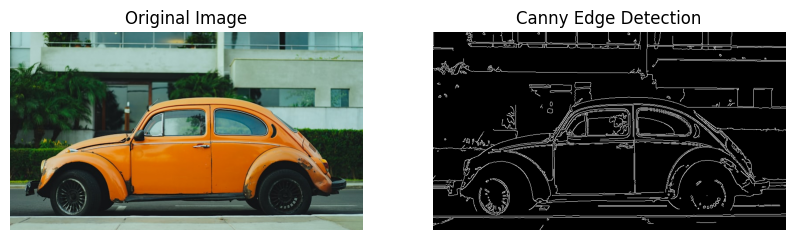

In [3]:
# Install libraries (only needed in Colab)
!pip install opencv-python matplotlib

import cv2
from matplotlib import pyplot as plt
import urllib.request
import urllib.error # Import urllib.error for specific exception handling

# -------------------------------
# 1. Download sample image
# -------------------------------
image_url = "https://images.unsplash.com/photo-1489824904134-891ab64532f1?auto=format&fit=crop&w=800&q=80"
# The error "HTTP Error 403: Forbidden" often occurs when a server blocks
# requests that don't have a common User-Agent header.
# We can spoof a browser User-Agent to bypass this.
try:
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
    req = urllib.request.Request(image_url, headers=headers)
    with urllib.request.urlopen(req) as response:
        with open("sample.jpg", "wb") as out_file:
            out_file.write(response.read())
except urllib.error.HTTPError as e:
    print(f"Error downloading image: {e}")
    print("Please check the image URL or try a different one.")
    exit()
except Exception as e:
    print(f"An unexpected error occurred during image download: {e}")
    exit()


# -------------------------------
# 2. Read image
# -------------------------------
img = cv2.imread("sample.jpg")

if img is None:
    print("Error loading image. The file 'sample.jpg' might not have been downloaded correctly or is corrupted.")
    exit()

# Convert original image to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -------------------------------
# 3. Convert to Gray-scale
# -------------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------------------------------
# 4. Apply Canny Edge Detection
# -------------------------------
edges = cv2.Canny(gray, 100, 200)

# -------------------------------
# 5. Display images
# -------------------------------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Canny Edge Detection")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.show()